In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
DARK_BG        = "#0d1117"
PANEL_BG       = "#161b22"
BORDER         = "#30363d"
TEXT_PRIMARY   = "#e6edf3"
TEXT_SECONDARY = "#8b949e"

ACCENT_RED    = "#ff4d4f"
ACCENT_ORANGE = "#fa8c16"
ACCENT_AMBER  = "#ffd666"
ACCENT_CYAN   = "#36cfc9"
ACCENT_BLUE   = "#4096ff"
ACCENT_VIOLET = "#9254de"
ACCENT_GREEN  = "#52c41a"

CONFLICT_PALETTE = {
    "War":           ACCENT_RED,
    "Civil War":     ACCENT_ORANGE,
    "Proxy War":     ACCENT_AMBER,
    "Skirmish":      ACCENT_CYAN,
    "Cold Conflict": ACCENT_BLUE,
}
OUTCOME_PALETTE = {
    "Victory_A": ACCENT_CYAN,
    "Victory_B": ACCENT_ORANGE,
    "Stalemate": ACCENT_VIOLET,
}
ZONE_PALETTE    = ["#ff6b6b", "#ffd93d", "#6bcb77", "#4d96ff"]
TERRAIN_PALETTE = ["#c9a227", "#4e8d7c", "#6a4c93", "#f77f00", "#1982c4"]

plt.rcParams.update({
    "figure.facecolor":  DARK_BG,
    "axes.facecolor":    PANEL_BG,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   TEXT_PRIMARY,
    "xtick.color":       TEXT_SECONDARY,
    "ytick.color":       TEXT_SECONDARY,
    "text.color":        TEXT_PRIMARY,
    "grid.color":        BORDER,
    "grid.linestyle":    "--",
    "grid.linewidth":    0.5,
    "font.family":       "DejaVu Sans",
    "legend.facecolor":  PANEL_BG,
    "legend.edgecolor":  BORDER,
    "legend.labelcolor": TEXT_PRIMARY,
})

def styled_ax(ax, title="", xlabel="", ylabel=""):
    ax.set_facecolor(PANEL_BG)
    for sp in ax.spines.values():
        sp.set_color(BORDER)
    if title:
        ax.set_title(title, color=TEXT_PRIMARY, fontsize=12, fontweight="bold", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, color=TEXT_SECONDARY, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=TEXT_SECONDARY, fontsize=9)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)
    return ax

In [3]:
df = pd.read_csv("/kaggle/input/datasets/khushikyad001/global-war-and-conflict-impact-dataset-19502024/global_conflicts_dataset.csv")

In [4]:
df["Total_Military_Deaths"] = df["Military_Deaths_A"] + df["Military_Deaths_B"]
df["Total_Deaths"]          = df["Total_Military_Deaths"] + df["Civilian_Deaths"]
df["Decade"]                = (df["Year"] // 10 * 10).astype(str) + "s"
df["Alliance_A"].fillna("Non-Aligned", inplace=True)
df["Alliance_B"].fillna("Non-Aligned", inplace=True)
df["Resource_Dispute"].fillna("None", inplace=True)
df.head()

,Country_A,Country_B,Conflict_Type,Year,Duration_Days,Military_Deaths_A,Military_Deaths_B,Civilian_Deaths,Economic_Loss_USD_Billions,Temperature_Avg_C,...,Ceasefire,Outcome,Latitude,Longitude,Climate_Zone,Resource_Dispute,UN_Involvement,Total_Military_Deaths,Total_Deaths,Decade
0,France,France,Cold Conflict,2020,1829,33197,41305,50364,176.45,8.2,...,No,Victory_A,88.811,101.020,Temperate,Land,Yes,74502,124866,2020s
1,India,Japan,Cold Conflict,2013,1234,26773,10526,176846,435.83,24.8,...,Yes,Stalemate,55.878,78.502,Polar,Water,No,37299,214145,2010s
2,Israel,USA,Civil War,1970,1982,17256,7604,17280,154.50,17.3,...,No,Stalemate,29.263,144.680,Tropical,Water,No,24860,42140,1970s
3,Turkey,Australia,Proxy War,2021,1754,1745,33468,92279,273.20,12.3,...,No,Victory_A,-22.281,-147.397,Polar,Water,No,35213,127492,2020s
4,Australia,France,War,2012,753,29149,40672,72545,351.35,31.1,...,No,Victory_A,17.638,169.360,Temperate,Land,No,69821,142366,2010s


In [5]:
df.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
Year,3000.000000,1987.338000,21.766006,1950.000000,1968.000000,1987.000000,2007.000000,2024.000000
Duration_Days,3000.000000,1003.734667,568.221869,2.000000,529.000000,999.000000,1493.000000,1999.000000
Military_Deaths_A,3000.000000,24423.385000,14129.940099,105.000000,12292.000000,23889.000000,36801.000000,49995.000000
Military_Deaths_B,3000.000000,24959.623333,14345.873994,119.000000,12768.250000,24270.000000,37424.500000,49992.000000
Civilian_Deaths,3000.000000,100151.649333,57927.462774,68.000000,49719.500000,100106.500000,149615.750000,199972.000000
Economic_Loss_USD_Billions,3000.000000,253.684450,142.903418,0.230000,132.905000,257.580000,374.897500,499.960000
Temperature_Avg_C,3000.000000,12.928667,13.094564,-10.000000,1.700000,13.000000,24.200000,35.000000
Rainfall_mm,3000.000000,1538.184333,862.818221,0.100000,796.725000,1547.650000,2282.350000,2999.000000
Population_A_Millions,3000.000000,709.784867,400.912716,2.600000,370.950000,711.300000,1053.525000,1400.000000
Population_B_Millions,3000.000000,697.569867,403.902829,1.100000,354.100000,699.850000,1050.025000,1399.700000


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].rename("Missing Count")
missing.to_frame().assign(Pct=lambda x: (x["Missing Count"] / len(df) * 100).round(2))

,Missing Count,Pct


In [7]:
kpis = {
    "Total Conflicts":       f"{len(df):,}",
    "Total Deaths":          f"{df['Total_Deaths'].sum()/1e6:.1f}M",
    "Economic Losses":       f"${df['Economic_Loss_USD_Billions'].sum():.0f}B",
    "Total Refugees":        f"{df['Refugees_Millions'].sum():.1f}M",
    "Avg Duration":          f"{df['Duration_Days'].mean():.0f} days",
    "Ceasefire Rate":        f"{(df['Ceasefire']=='Yes').mean()*100:.0f}%",
    "UN Involvement Rate":   f"{(df['UN_Involvement']=='Yes').mean()*100:.0f}%",
}
pd.DataFrame(kpis.items(), columns=["Metric", "Value"]).set_index("Metric")

,Value
Metric,
Total Conflicts,"3,000"
Total Deaths,448.6M
Economic Losses,$761053B
Total Refugees,30248.0M
Avg Duration,1004 days
Ceasefire Rate,48%
UN Involvement Rate,50%


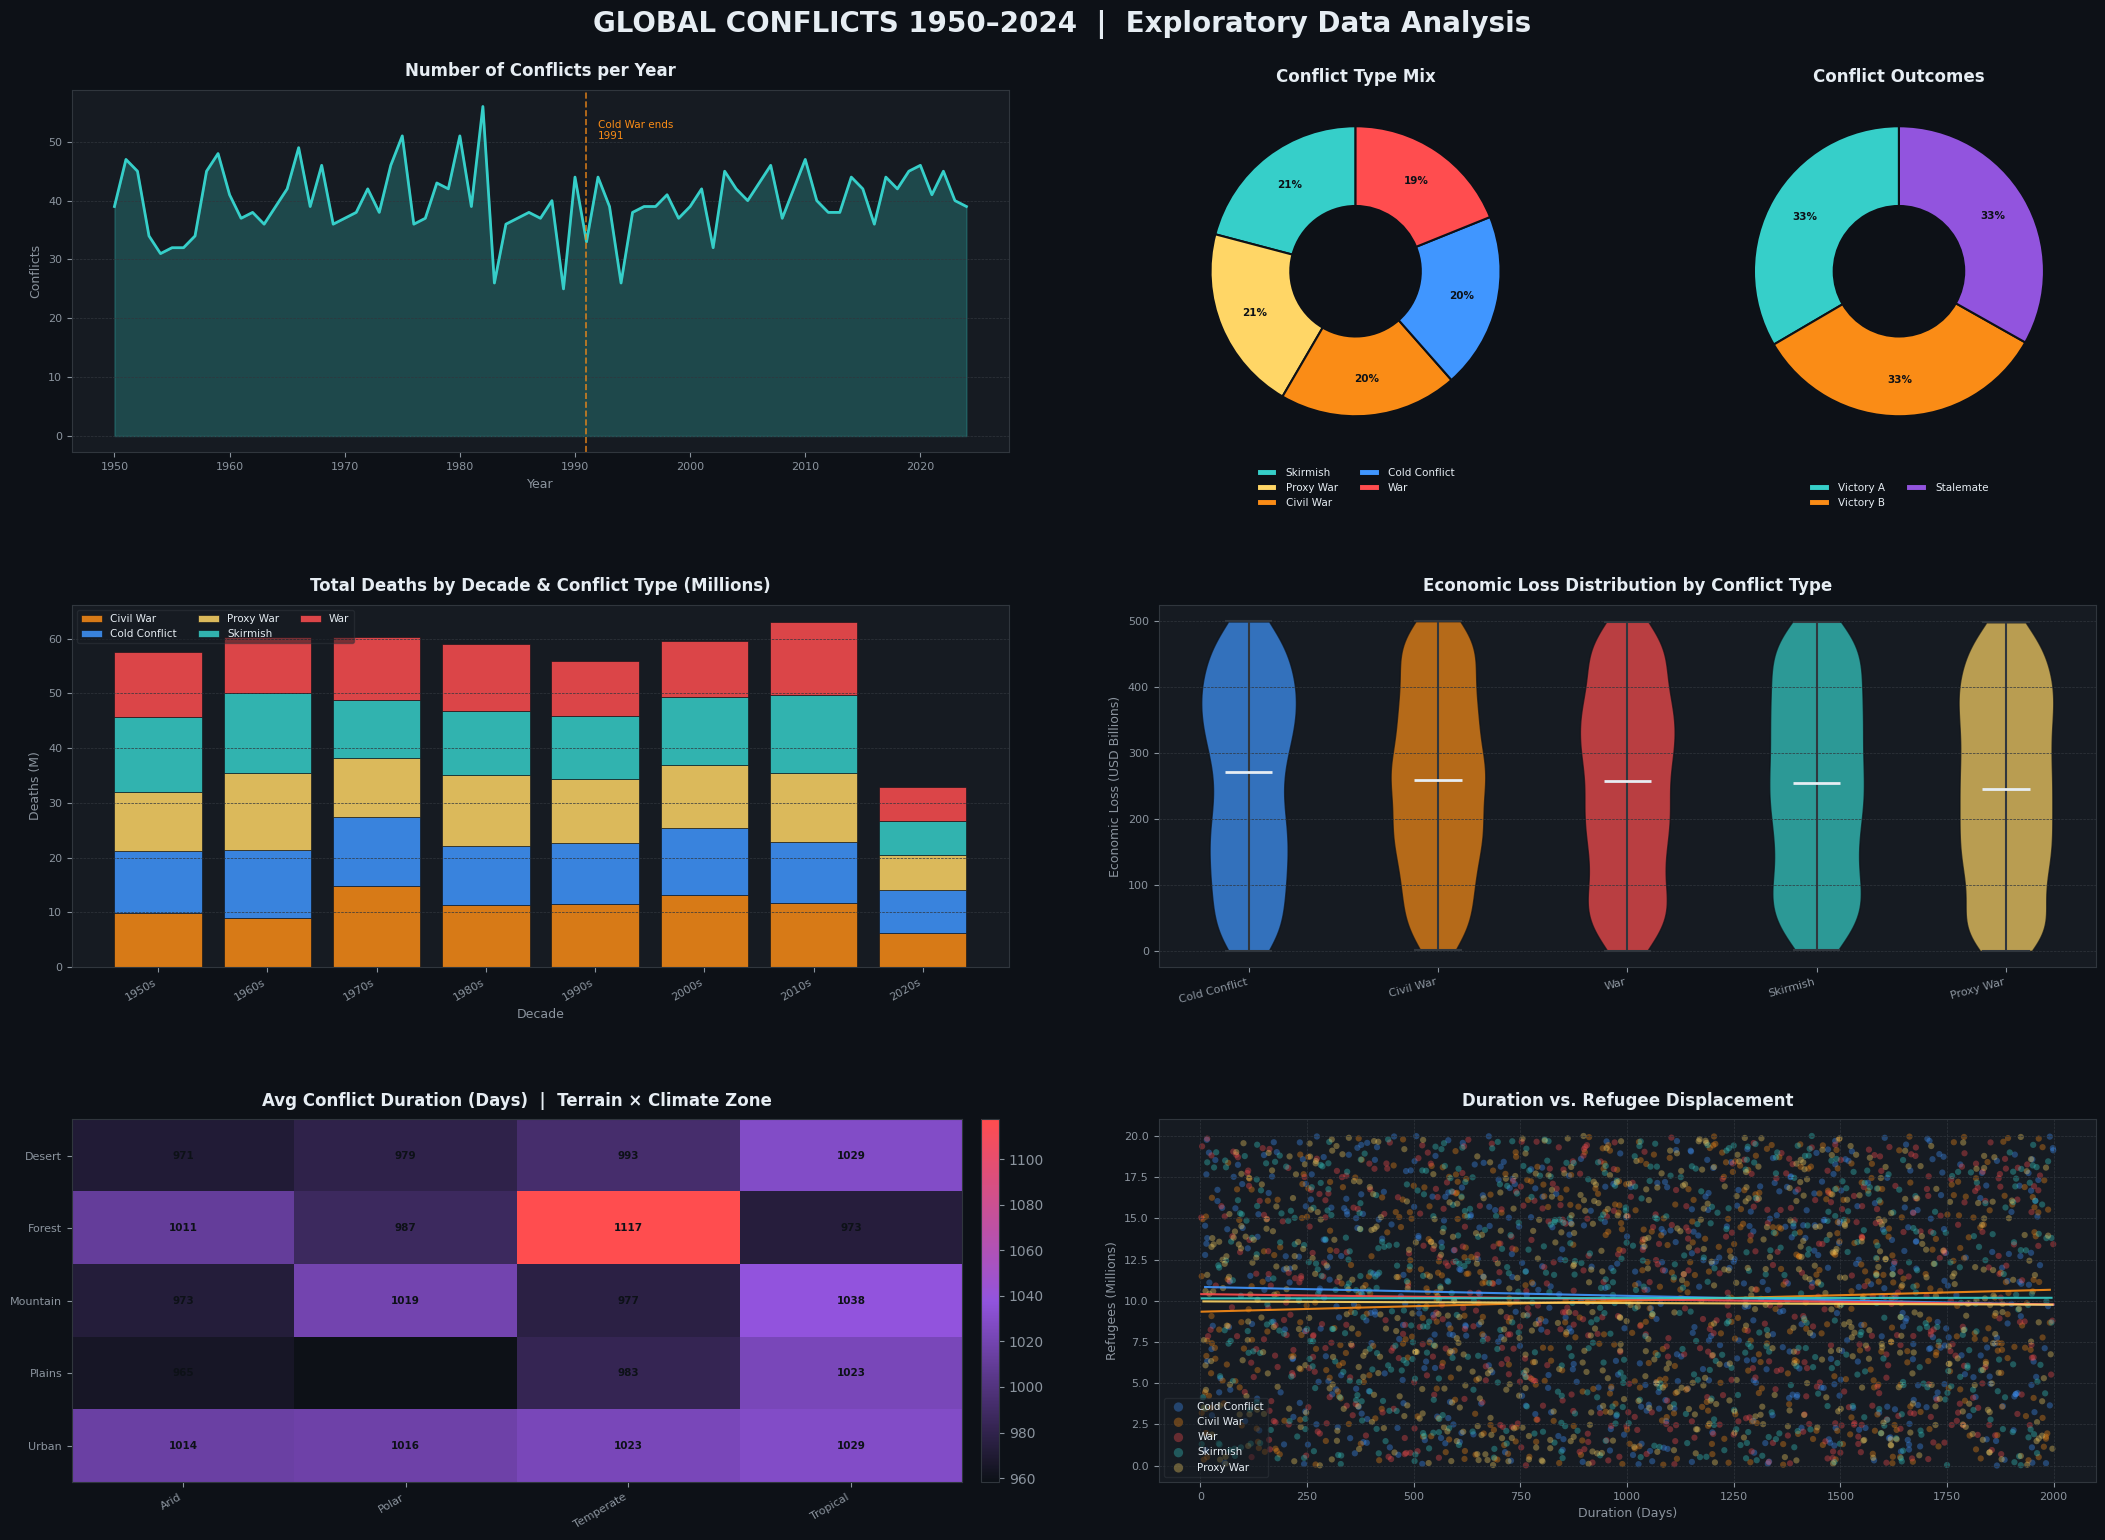

In [8]:
fig = plt.figure(figsize=(22, 16), facecolor=DARK_BG)
fig.suptitle("GLOBAL CONFLICTS 1950–2024  |  Exploratory Data Analysis",
             fontsize=20, fontweight="bold", color=TEXT_PRIMARY, y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.42, wspace=0.38,
                       left=0.05, right=0.97, top=0.93, bottom=0.06)

# Conflicts per year
ax1 = fig.add_subplot(gs[0, :2])
yearly = df.groupby("Year").size().reset_index(name="Count")
ax1.fill_between(yearly["Year"], yearly["Count"], alpha=0.25, color=ACCENT_CYAN)
ax1.plot(yearly["Year"], yearly["Count"], color=ACCENT_CYAN, lw=2)
ax1.axvline(1991, color=ACCENT_ORANGE, lw=1.2, ls="--", alpha=0.8)
ax1.text(1992, yearly["Count"].max() * 0.9, "Cold War ends\n1991",
         color=ACCENT_ORANGE, fontsize=7.5)
styled_ax(ax1, "Number of Conflicts per Year", "Year", "Conflicts")
ax1.grid(True, axis="y")

# Conflict type donut
ax2 = fig.add_subplot(gs[0, 2])
ct_counts = df["Conflict_Type"].value_counts()
wedge_colors = [CONFLICT_PALETTE[c] for c in ct_counts.index]
wedges, _, autotexts = ax2.pie(
    ct_counts, labels=None, autopct="%1.0f%%",
    colors=wedge_colors, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=DARK_BG, linewidth=1.5),
    pctdistance=0.75)
for at in autotexts:
    at.set(fontsize=7.5, color=DARK_BG, fontweight="bold")
ax2.legend(ct_counts.index, loc="lower center", bbox_to_anchor=(0.5, -0.18),
           fontsize=7.5, ncol=2, frameon=False)
ax2.set_facecolor(PANEL_BG)
ax2.set_title("Conflict Type Mix", color=TEXT_PRIMARY, fontsize=12, fontweight="bold")

# Outcome donut
ax3 = fig.add_subplot(gs[0, 3])
oc_counts = df["Outcome"].value_counts()
oc_colors  = [OUTCOME_PALETTE[c] for c in oc_counts.index]
wedges2, _, autotexts2 = ax3.pie(
    oc_counts, labels=None, autopct="%1.0f%%",
    colors=oc_colors, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=DARK_BG, linewidth=1.5),
    pctdistance=0.75)
for at in autotexts2:
    at.set(fontsize=7.5, color=DARK_BG, fontweight="bold")
ax3.legend([o.replace("_", " ") for o in oc_counts.index],
           loc="lower center", bbox_to_anchor=(0.5, -0.18),
           fontsize=7.5, ncol=2, frameon=False)
ax3.set_facecolor(PANEL_BG)
ax3.set_title("Conflict Outcomes", color=TEXT_PRIMARY, fontsize=12, fontweight="bold")

# Deaths by decade (stacked bars)
ax4 = fig.add_subplot(gs[1, :2])
decade_type = df.groupby(["Decade", "Conflict_Type"])["Total_Deaths"].sum().unstack(fill_value=0)
decades_sorted = sorted(decade_type.index)
decade_type = decade_type.loc[decades_sorted]
bottom = np.zeros(len(decade_type))
x = np.arange(len(decade_type))
for ctype in decade_type.columns:
    vals = decade_type[ctype].values / 1e6
    ax4.bar(x, vals, bottom=bottom, color=CONFLICT_PALETTE.get(ctype, "#888"),
            label=ctype, alpha=0.85, width=0.8, edgecolor=DARK_BG, linewidth=0.5)
    bottom += vals
ax4.set_xticks(x)
ax4.set_xticklabels(decades_sorted, rotation=30, ha="right")
styled_ax(ax4, "Total Deaths by Decade & Conflict Type (Millions)", "Decade", "Deaths (M)")
ax4.legend(fontsize=7.5, ncol=3, loc="upper left", framealpha=0.5)
ax4.grid(True, axis="y")

# Economic loss violin
ax5 = fig.add_subplot(gs[1, 2:])
order = df.groupby("Conflict_Type")["Economic_Loss_USD_Billions"].median() \
          .sort_values(ascending=False).index.tolist()
parts = ax5.violinplot(
    [df[df["Conflict_Type"] == c]["Economic_Loss_USD_Billions"].values for c in order],
    positions=range(len(order)), showmedians=True, showextrema=True)
for pc, ctype in zip(parts["bodies"], order):
    pc.set_facecolor(CONFLICT_PALETTE[ctype]); pc.set_alpha(0.7); pc.set_edgecolor(DARK_BG)
parts["cmedians"].set_colors(TEXT_PRIMARY); parts["cmedians"].set_linewidth(2)
for part in ["cbars", "cmaxes", "cmins"]:
    parts[part].set_colors(BORDER)
ax5.set_xticks(range(len(order)))
ax5.set_xticklabels(order, rotation=15, ha="right", fontsize=8)
styled_ax(ax5, "Economic Loss Distribution by Conflict Type", "", "Economic Loss (USD Billions)")
ax5.grid(True, axis="y")

# Duration heatmap (terrain × climate)
ax6 = fig.add_subplot(gs[2, :2])
pivot = df.pivot_table(values="Duration_Days", index="Terrain_Type",
                       columns="Climate_Zone", aggfunc="mean")
cmap_heat = LinearSegmentedColormap.from_list("heat", ["#0d1117", ACCENT_VIOLET, ACCENT_RED])
im = ax6.imshow(pivot.values, cmap=cmap_heat, aspect="auto")
ax6.set_xticks(range(len(pivot.columns))); ax6.set_yticks(range(len(pivot.index)))
ax6.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=8)
ax6.set_yticklabels(pivot.index, fontsize=8)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax6.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7.5,
                 color="white" if val < pivot.values.max() * 0.6 else DARK_BG, fontweight="bold")
plt.colorbar(im, ax=ax6, fraction=0.03, pad=0.02).ax.tick_params(colors=TEXT_SECONDARY)
styled_ax(ax6, "Avg Conflict Duration (Days)  |  Terrain × Climate Zone")

# Duration vs refugee displacement
ax7 = fig.add_subplot(gs[2, 2:])
for ctype in order:
    sub = df[df["Conflict_Type"] == ctype]
    ax7.scatter(sub["Duration_Days"], sub["Refugees_Millions"],
                alpha=0.35, s=20, color=CONFLICT_PALETTE[ctype], label=ctype, edgecolors="none")
    z = np.polyfit(sub["Duration_Days"], sub["Refugees_Millions"], 1)
    xs = np.linspace(sub["Duration_Days"].min(), sub["Duration_Days"].max(), 100)
    ax7.plot(xs, np.poly1d(z)(xs), color=CONFLICT_PALETTE[ctype], lw=1.5, alpha=0.9)
styled_ax(ax7, "Duration vs. Refugee Displacement", "Duration (Days)", "Refugees (Millions)")
ax7.legend(fontsize=7.5, markerscale=1.5, framealpha=0.5)
ax7.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

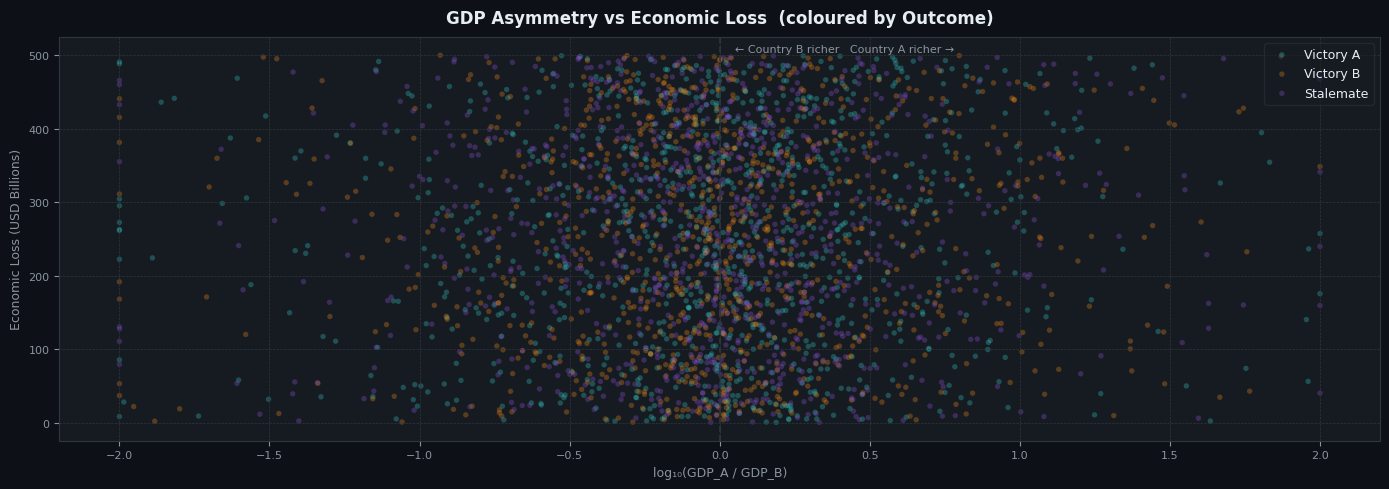

In [9]:
df["GDP_Ratio"]     = df["GDP_A_Billions"] / (df["GDP_B_Billions"] + 1)
df["GDP_Ratio_log"] = np.log10(df["GDP_Ratio"].clip(0.01, 100))

fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK_BG)
for outcome, color in OUTCOME_PALETTE.items():
    sub = df[df["Outcome"] == outcome]
    ax.scatter(sub["GDP_Ratio_log"], sub["Economic_Loss_USD_Billions"],
               alpha=0.3, s=15, color=color, label=outcome.replace("_", " "), edgecolors="none")
ax.axvline(0, color=BORDER, lw=1.2, ls="--")
ax.text(0.05, ax.get_ylim()[1] * 0.96, "← Country B richer   Country A richer →",
        color=TEXT_SECONDARY, fontsize=8)
styled_ax(ax, "GDP Asymmetry vs Economic Loss  (coloured by Outcome)",
          "log₁₀(GDP_A / GDP_B)", "Economic Loss (USD Billions)")
ax.legend(fontsize=9, framealpha=0.5)
ax.grid(True)
plt.tight_layout()
plt.show()

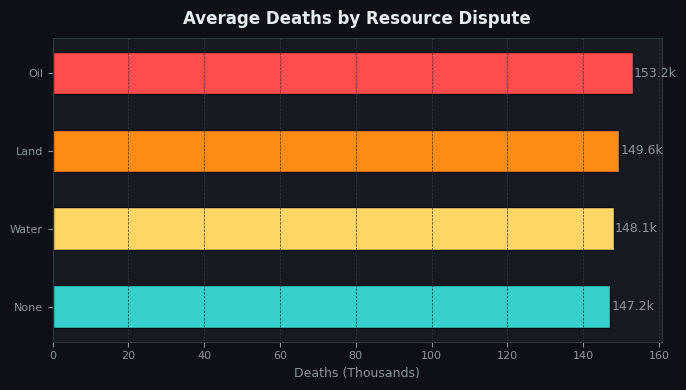

In [10]:
fig, ax = plt.subplots(figsize=(7, 4), facecolor=DARK_BG)
res_death = df.groupby("Resource_Dispute")["Total_Deaths"].mean().sort_values()
colors_res = [ACCENT_CYAN, ACCENT_AMBER, ACCENT_ORANGE, ACCENT_RED]
bars = ax.barh(res_death.index, res_death.values / 1e3, color=colors_res,
               edgecolor=DARK_BG, height=0.55)
for bar, val in zip(bars, res_death.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val/1e3:.1f}k", va="center", fontsize=9, color=TEXT_SECONDARY)
styled_ax(ax, "Average Deaths by Resource Dispute", "Deaths (Thousands)", "")
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()

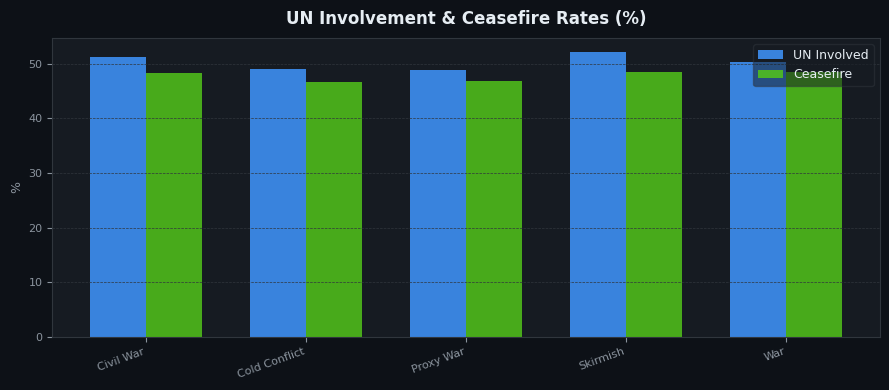

In [11]:
fig, ax = plt.subplots(figsize=(9, 4), facecolor=DARK_BG)
un_cf = df.groupby("Conflict_Type").agg(
    UN_Rate=("UN_Involvement", lambda x: (x == "Yes").mean() * 100),
    CF_Rate=("Ceasefire",      lambda x: (x == "Yes").mean() * 100),
).reset_index()
x = np.arange(len(un_cf)); w = 0.35
ax.bar(x - w/2, un_cf["UN_Rate"], width=w, color=ACCENT_BLUE,  label="UN Involved", alpha=0.85)
ax.bar(x + w/2, un_cf["CF_Rate"], width=w, color=ACCENT_GREEN, label="Ceasefire",   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(un_cf["Conflict_Type"], rotation=20, ha="right")
styled_ax(ax, "UN Involvement & Ceasefire Rates (%)", "", "%")
ax.legend(fontsize=9, framealpha=0.5)
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

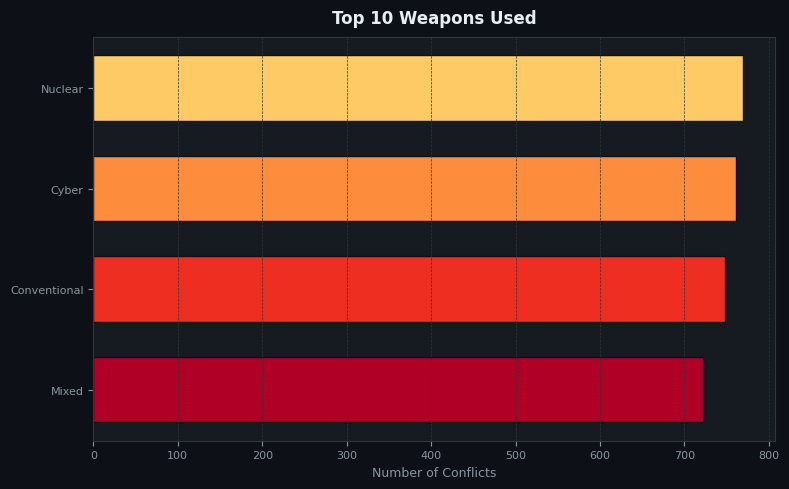

In [12]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor=DARK_BG)
weapon_counts = df["Weapons_Used"].value_counts().head(10)
bar_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(weapon_counts)))
ax.barh(weapon_counts.index[::-1], weapon_counts.values[::-1],
        color=bar_colors[::-1], edgecolor=DARK_BG, height=0.65)
styled_ax(ax, "Top 10 Weapons Used", "Number of Conflicts", "")
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()

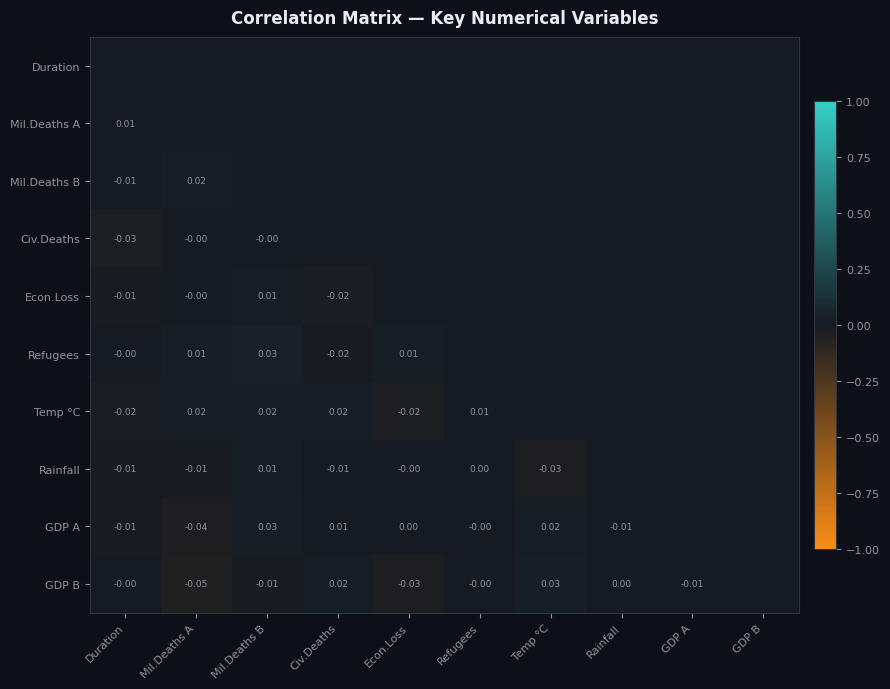

In [13]:
num_cols = ["Duration_Days","Military_Deaths_A","Military_Deaths_B","Civilian_Deaths",
            "Economic_Loss_USD_Billions","Refugees_Millions","Temperature_Avg_C",
            "Rainfall_mm","GDP_A_Billions","GDP_B_Billions"]
corr = df[num_cols].corr()
short = {
    "Duration_Days":"Duration","Military_Deaths_A":"Mil.Deaths A",
    "Military_Deaths_B":"Mil.Deaths B","Civilian_Deaths":"Civ.Deaths",
    "Economic_Loss_USD_Billions":"Econ.Loss","Refugees_Millions":"Refugees",
    "Temperature_Avg_C":"Temp °C","Rainfall_mm":"Rainfall",
    "GDP_A_Billions":"GDP A","GDP_B_Billions":"GDP B",
}
corr.rename(index=short, columns=short, inplace=True)

fig, ax = plt.subplots(figsize=(9, 7), facecolor=DARK_BG)
cmap_div = LinearSegmentedColormap.from_list("div", [ACCENT_ORANGE, PANEL_BG, ACCENT_CYAN])
mask = np.triu(np.ones_like(corr, dtype=bool))
im2 = ax.imshow(np.where(mask, np.nan, corr.values), cmap=cmap_div, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        if not mask[i, j]:
            val = corr.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6.5,
                    color=DARK_BG if abs(val) > 0.5 else TEXT_SECONDARY)
plt.colorbar(im2, ax=ax, fraction=0.03, pad=0.02).ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)
styled_ax(ax, "Correlation Matrix — Key Numerical Variables")
plt.tight_layout()
plt.show()

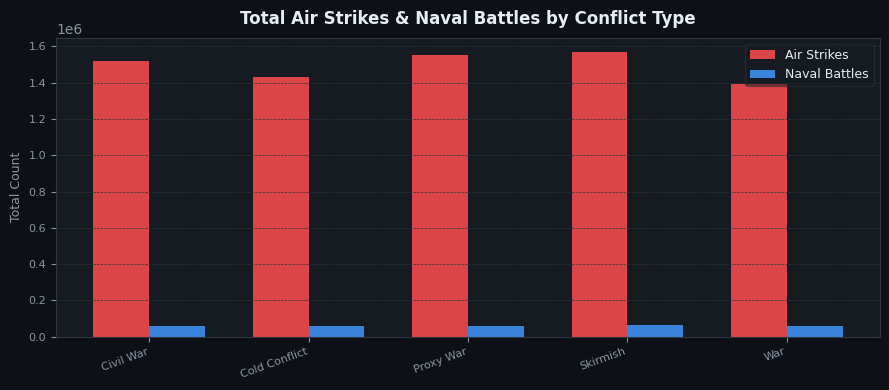

In [14]:
fig, ax = plt.subplots(figsize=(9, 4), facecolor=DARK_BG)
mil_ops = df.groupby("Conflict_Type")[["Air_Strikes", "Naval_Battles"]].sum()
x = np.arange(len(mil_ops)); w = 0.35
ax.bar(x - w/2, mil_ops["Air_Strikes"],   width=w, color=ACCENT_RED,  label="Air Strikes",   alpha=0.85)
ax.bar(x + w/2, mil_ops["Naval_Battles"], width=w, color=ACCENT_BLUE, label="Naval Battles", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(mil_ops.index, rotation=20, ha="right")
styled_ax(ax, "Total Air Strikes & Naval Battles by Conflict Type", "", "Total Count")
ax.legend(fontsize=9, framealpha=0.5)
ax.grid(True, axis="y")
plt.tight_layout(); plt.show()

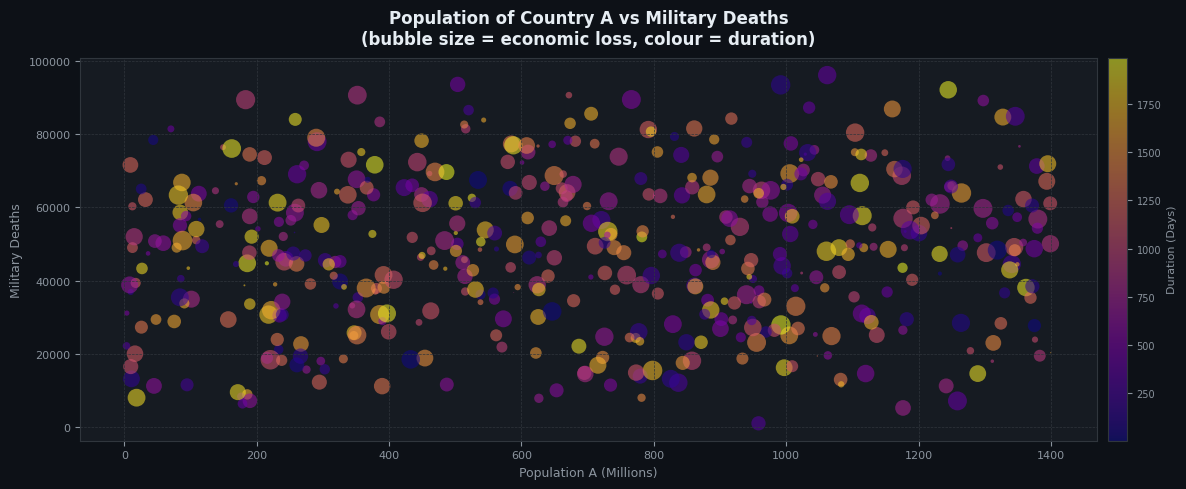

In [15]:
fig, ax = plt.subplots(figsize=(12, 5), facecolor=DARK_BG)
sample = df.sample(500, random_state=42)
sc = ax.scatter(
    sample["Population_A_Millions"], sample["Total_Military_Deaths"],
    s=sample["Economic_Loss_USD_Billions"] * 0.4,
    c=sample["Duration_Days"], cmap="plasma", alpha=0.55, edgecolors="none")
cb = plt.colorbar(sc, ax=ax, fraction=0.025, pad=0.01)
cb.set_label("Duration (Days)", color=TEXT_SECONDARY, fontsize=8)
cb.ax.tick_params(colors=TEXT_SECONDARY, labelsize=7)
styled_ax(ax,
    "Population of Country A vs Military Deaths\n(bubble size = economic loss, colour = duration)",
    "Population A (Millions)", "Military Deaths")
ax.grid(True)
plt.tight_layout()
plt.show()

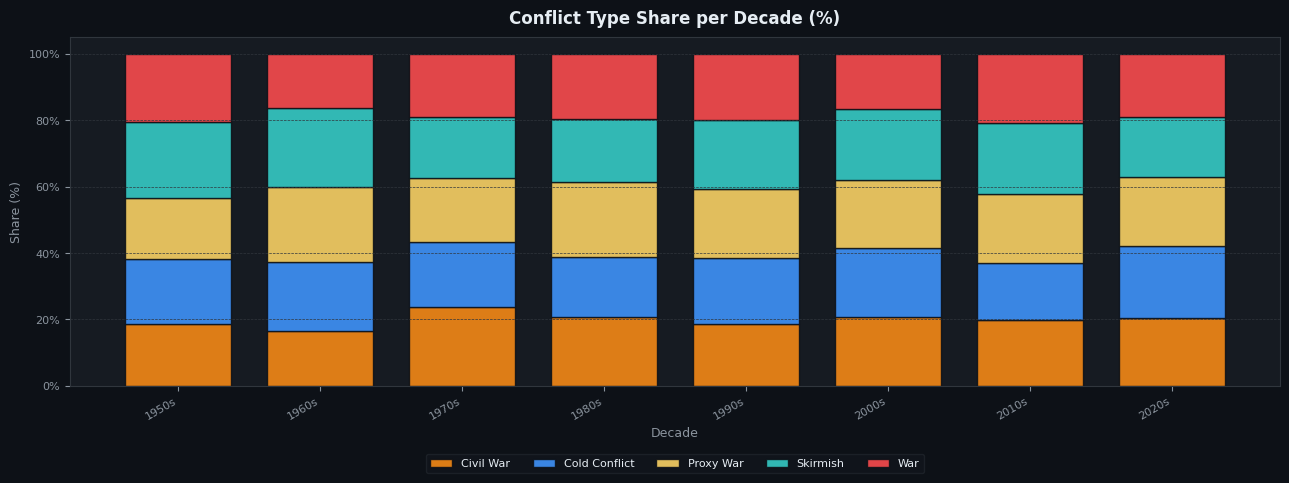

In [16]:
fig, ax = plt.subplots(figsize=(13, 5), facecolor=DARK_BG)
dec_type_pct = df.groupby(["Decade", "Conflict_Type"]).size().unstack(fill_value=0)
dec_type_pct = dec_type_pct.div(dec_type_pct.sum(axis=1), axis=0) * 100
dec_type_pct = dec_type_pct.loc[sorted(dec_type_pct.index)]
x = np.arange(len(dec_type_pct))
bottom = np.zeros(len(dec_type_pct))
for ct in dec_type_pct.columns:
    ax.bar(x, dec_type_pct[ct], bottom=bottom,
           color=CONFLICT_PALETTE[ct], label=ct, alpha=0.88, width=0.75, edgecolor=DARK_BG)
    bottom += dec_type_pct[ct].values
ax.set_xticks(x)
ax.set_xticklabels(sorted(dec_type_pct.index), rotation=30, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
styled_ax(ax, "Conflict Type Share per Decade (%)", "Decade", "Share (%)")
ax.legend(fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18), framealpha=0.4)
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

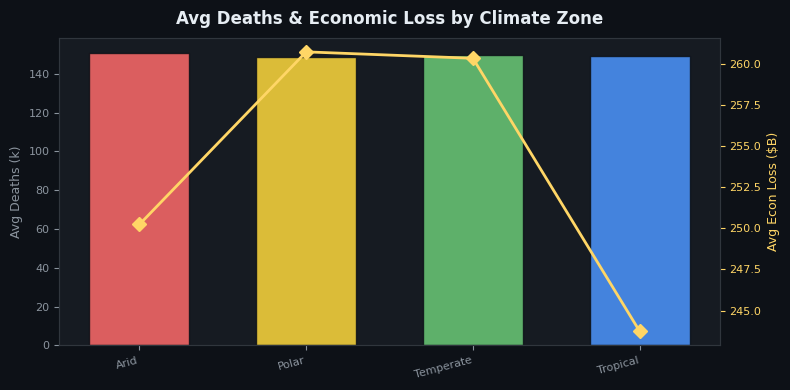

In [17]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor=DARK_BG)
climate_stats = df.groupby("Climate_Zone").agg(
    Deaths=("Total_Deaths", "mean"),
    EconLoss=("Economic_Loss_USD_Billions", "mean")).reset_index()
x = np.arange(len(climate_stats))
ax.bar(x, climate_stats["Deaths"] / 1e3, color=ZONE_PALETTE, alpha=0.85, edgecolor=DARK_BG, width=0.6)
ax_twin = ax.twinx()
ax_twin.plot(x, climate_stats["EconLoss"], color=ACCENT_AMBER, lw=2, marker="D", markersize=7, zorder=5)
ax_twin.tick_params(colors=ACCENT_AMBER, labelsize=8)
ax_twin.set_ylabel("Avg Econ Loss ($B)", color=ACCENT_AMBER, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(climate_stats["Climate_Zone"], rotation=15, ha="right")
styled_ax(ax, "Avg Deaths & Economic Loss by Climate Zone", "", "Avg Deaths (k)")
plt.tight_layout()
plt.show()

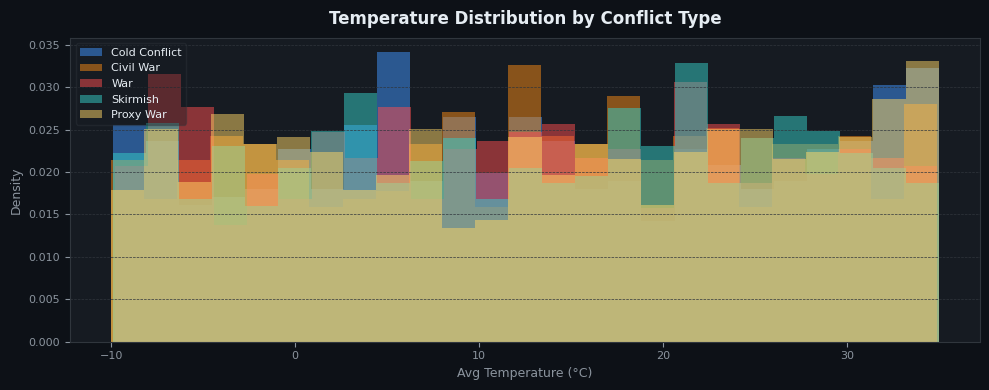

In [18]:
fig, ax = plt.subplots(figsize=(10, 4), facecolor=DARK_BG)
order = df.groupby("Conflict_Type")["Economic_Loss_USD_Billions"].median() \
          .sort_values(ascending=False).index.tolist()
for ctype in order:
    vals = df[df["Conflict_Type"] == ctype]["Temperature_Avg_C"]
    ax.hist(vals, bins=25, alpha=0.5, color=CONFLICT_PALETTE[ctype], label=ctype, density=True)
styled_ax(ax, "Temperature Distribution by Conflict Type", "Avg Temperature (°C)", "Density")
ax.legend(fontsize=8, framealpha=0.4)
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

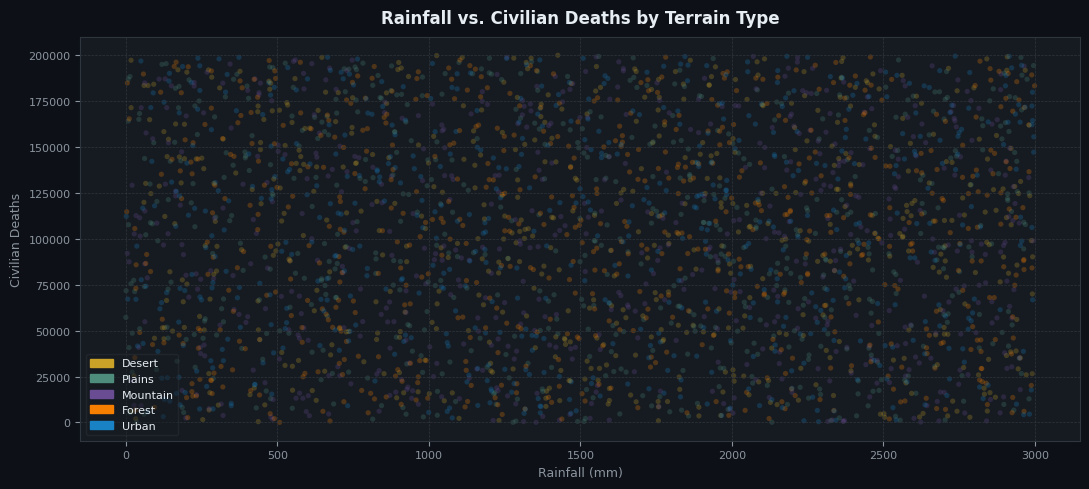

In [19]:
fig, ax = plt.subplots(figsize=(11, 5), facecolor=DARK_BG)
terrains = df["Terrain_Type"].unique()
terrain_colors = dict(zip(terrains, TERRAIN_PALETTE))
for terrain in terrains:
    sub = df[df["Terrain_Type"] == terrain]
    ax.scatter(sub["Rainfall_mm"], sub["Civilian_Deaths"],
               alpha=0.25, s=14, color=terrain_colors[terrain], label=terrain, edgecolors="none")
handles = [mpatches.Patch(color=terrain_colors[t], label=t) for t in terrains]
ax.legend(handles=handles, fontsize=8, framealpha=0.4)
styled_ax(ax, "Rainfall vs. Civilian Deaths by Terrain Type", "Rainfall (mm)", "Civilian Deaths")
ax.grid(True)
plt.tight_layout()
plt.show()

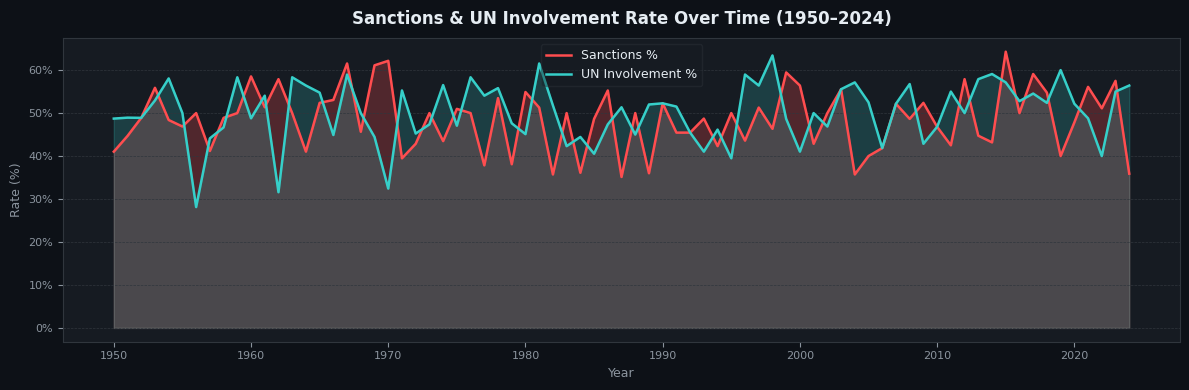

In [20]:
fig, ax = plt.subplots(figsize=(12, 4), facecolor=DARK_BG)
sanc_year = df.groupby("Year").apply(lambda g: (g["Sanctions"] == "Yes").mean() * 100)
un_year   = df.groupby("Year").apply(lambda g: (g["UN_Involvement"] == "Yes").mean() * 100)
ax.fill_between(sanc_year.index, sanc_year, alpha=0.25, color=ACCENT_RED)
ax.plot(sanc_year.index, sanc_year, color=ACCENT_RED, lw=1.8, label="Sanctions %")
ax.fill_between(un_year.index, un_year, alpha=0.20, color=ACCENT_CYAN)
ax.plot(un_year.index, un_year, color=ACCENT_CYAN, lw=1.8, label="UN Involvement %")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.legend(fontsize=9, framealpha=0.4)
styled_ax(ax, "Sanctions & UN Involvement Rate Over Time (1950–2024)", "Year", "Rate (%)")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()